# Experiment No: 1 Convergence Analysis of Sigmoid and Hyperbolic Tangent Non Linear Activation Function

### Reason for experimentation
We know that Hyperbolic Tangent (Tanh) has an output range of (-1, 1) and centered around 0 where as sigmoid has a range of (0, 1) and is centered around 0.5. Due to this very reason **Tanh** activation function is said to **converge faster** than **Sigmoid** activation function.

To see if this is really true this experiment is being done.

### Experiment Design
The following procedures will be carried out for the experiment:
1. Classification models will be evaluated on four types of datasets:
    1. **Circle**: A central cluster of blue points surrounded by a ring of orange points.
    2. **Exclusive** OR **(XOR)**: Data points arranged in four quadrants, where opposite corners share the same label.
    3. **Gaussian**: Two distinct, linearly separable clusters.
    4. **Spiral**: Two intertwined spirals of blue and orange points; this is typically the most challenging pattern for simple models.
2. Each experiment will be repeated **3** times, and the average result will be reported to reduce the effect of randomness.
3. Experiments will be conducted on datasets of size **500**, **1,000** and **2,000** data points.
4. Four batch sizes will be used: **32**, **64** and **128**.
5. Four learning rates will be used: **0.003**, **0.01**, and **0.03**.

The following parameters will remain constant:
1. Number of input features: **7**
2. Neural network architecture: **2** hidden layers with **8** neurons each and last layer with a **2**.
3. The entire dataset will be used for training.
    1. train-test split of the dataset will not contribute towards the conclusion of the experiment and will only unneccessarily to the complexity of the experiment
4. Stocastic Gradient Descent Optimizer will be used (As we dont want the influence of other types of optimizers on the speed of convergence)
5. For classification tasks we will use **BCEWithLogitLoss** function.


### Convergence Thresholds
1. Convergence is defined as the point at which a predefined performance threshold is reached.
    1. Classification tasks: Accuracy ≥ **90**%

For each experiment, the number of epochs required to reach the threshold is recorded.
Maximum numberumber of epochs that an experiment can run is 1000.
If the threshold is not reached within the maximum number of epochs, the run is marked as not converged.


## Import libraries to be used throughout the experiment

In [1]:
import json
import time
import tqdm
import torch
import random
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm.notebook import tqdm
from torch.utils.data import Dataset
from typing import Self, Tuple, Literal
from sklearn.datasets import make_circles, make_moons, make_blobs

%matplotlib inline

## Result storage path

In [2]:
current_dir = Path.cwd()
result_path = current_dir.parent / 'results'/ '01_convergence_analysis_sigmoid_vs_tanh.json'
result_abs_path = result_path.absolute()

## Classes to be used throughout the experiment

### Neural Network Model Classes

- These classes represent ANN architecture which will be used for regression and classification tasks.
- There are 4 classes:
    1. SigmoidRegressionModel
    2. SigmoidClassificationModel
    3. TanhRegressionModel
    4. TanhClassificationModel

In [3]:
class SigmoidClassificationModel(torch.nn.Module):
    """
    Class representing an ANN for classification task with sigmoid non linear activation function.
    """

    def __init__(self) -> Self:
        """
        Method to instantiate an instance of :class: SigmoidClassificationModel

        :returns: Instance of :class: SigmoidClassificationModel
        """

        super().__init__()

        self.sequential_layer = torch.nn.Sequential(
                                    torch.nn.Linear(in_features=7, out_features=8),
                                    torch.nn.Sigmoid(),
                                    torch.nn.Linear(in_features=8, out_features=8),
                                    torch.nn.Sigmoid(),
                                    torch.nn.Linear(in_features=8, out_features=2)
                                    )
    
    def forward(self, X: torch.Tensor) -> torch.Tensor:
        """
        Method to perform forward propagation.

        :param X: Input Tensor

        :returns: Result of forward propagation on the input tensor `X`
        """
    
        return self.sequential_layer.forward(X)


class TanhClassificationModel(torch.nn.Module):
    """
    Class representing an ANN for classification task with hyperbolic tangent (Tanh) non linear activation function.
    """

    def __init__(self) -> Self:
        """
        Method to instantiate an instance of :class: TanhClassificationModel

        :returns: Instance of :class: TanhClassificationModel
        """

        super().__init__()

        self.sequential_layer = torch.nn.Sequential(
                                    torch.nn.Linear(in_features=7, out_features=8),
                                    torch.nn.Tanh(),
                                    torch.nn.Linear(in_features=8, out_features=8),
                                    torch.nn.Tanh(),
                                    torch.nn.Linear(in_features=8, out_features=2)
                                    )
    
    def forward(self, X: torch.Tensor) -> torch.Tensor:
        """
        Method to perform forward propagation.

        :param X: Input Tensor

        :returns: Result of forward propagation on the input tensor `X`
        """
    
        return self.sequential_layer.forward(X)


### Dataset classes

These classes will represent datasets which will be used to create and load dataset into a `DataLoader` for regression and classification task

In [4]:
# Classification Datasets
class CircleDataset(Dataset):
    """
    Class that is used to create a circle dataset for a binary classification task.

    The dataset has features and target of the shape (sample_size, 7) and (sample_size,) respectively
    """

    def __init__(self, sample_size: int, random_state: int = 42) -> Self:
        """
        Method to instantiate :class: CircleDataset

        :param sample_size: Size of the dataset to be created
        :param random_state: State to generate reproducible dataset

        :returns: Instance of :class: CircleDataset
        """

        super().__init__()

        # Initialize features and target
        self.X = torch.empty(size=(sample_size, 7))
        self.y = torch.empty(size=(sample_size,))
        self.sample_size = sample_size
        # Generate data
        self._generate_data(sample_size=sample_size, random_state=random_state)

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Method to extract feature and target value stored at `index` position.

        The returned value shape is ((1, 7), (1, 2)) representing 7 features and 2 target values due 
        to one hot encoding of the classes

        :param index: Position from which data needs to be returned

        :returns: Tuple containing feature and target value stored at `index`
        """
    
        return self.X[index], torch.nn.functional.one_hot(self.y[index], num_classes=2).to(torch.float32)

    def __len__(self) -> int:
        """
        Method to get the length of the dataset

        :returns: length of the dataset
        """

        return self.sample_size

    def _generate_data(self, sample_size: int, random_state: int = 42) -> bool:
        """
        Private method to generate a circle dataset.

        The features in X will be:
        1. X1 = Feature X1
        2. X2 = Feature X2
        3. X1^2 = Power(X1, 2)
        4. X2^2 = Power(X2, 2)
        5. X1*X2 = X1 x X2
        6. sin(X1) = sine of X1
        7. sin(X2) = sine of X2

        :param sample_size: Size of the dataset to be generated
        :param random_state: State to generate reproducible dataset

        :returns a boolean representing completion of dataset generation
        """

        X, y = make_circles(n_samples=sample_size, noise=0.05, random_state=random_state)

        feature_3 = np.pow(X[:, 0], 2).reshape(-1, 1)
        feature_4 = np.pow(X[:, 1], 2).reshape(-1, 1)
        feature_5 = (X[:, 0] * X[:, 1]).reshape(-1, 1)
        feature_6 = np.sin(X[:, 0]).reshape(-1, 1)
        feature_7 = np.sin(X[:, 1]).reshape(-1, 1)

        feature_set = np.hstack((X, feature_3, feature_4, feature_5, feature_6, feature_7))

        self.X = torch.from_numpy(feature_set).to(torch.float32)
        self.y = torch.from_numpy(y).to(torch.long)

        return True

    def get_complete_dataset(self) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Method that returns the complete dataset back to the user

        :returns: Tuple containing features and target present in the dataset
        """

        return self.X, self.y

class XORDataset(Dataset):
    """
    Class that is used to create a XOR dataset for a binary classification task.

    The dataset has features and target of the shape (sample_size, 7) and (sample_size,) respectively
    """

    def __init__(self, sample_size: int, random_state: int = 42) -> Self:
        """
        Method to instantiate :class: XORDataset

        :param sample_size: Size of the dataset to be created
        :param random_state: State to generate reproducible dataset

        :returns: Instance of :class: XORDataset
        """

        super().__init__()

        # Initialize features and target
        self.X = torch.empty(size=(sample_size, 7))
        self.y = torch.empty(size=(sample_size,))
        self.sample_size = sample_size
        # Generate data
        self._generate_data(sample_size=sample_size, random_state=random_state)

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Method to extract feature and target value stored at `index` position

        The returned value shape is ((1, 7), (1, 2)) representing 7 features and 2 target values due 
        to one hot encoding of the classes        

        :param index: Position from which data needs to be returned

        :returns: Tuple containing feature and target value stored at `index`
        """
    
        return self.X[index], torch.nn.functional.one_hot(self.y[index], num_classes=2).to(torch.float32)

    def __len__(self) -> int:
        """
        Method to get the length of the dataset

        :returns: length of the dataset
        """

        return self.sample_size

    def _generate_data(self, sample_size: int, random_state: int = 42) -> bool:
        """
        Private method to generate a XOR dataset.

        The features in X will be:
        1. X1 = Feature X1
        2. X2 = Feature X2
        3. X1^2 = Power(X1, 2)
        4. X2^2 = Power(X2, 2)
        5. X1*X2 = X1 x X2
        6. sin(X1) = sine of X1
        7. sin(X2) = sine of X2

        :param sample_size: Size of the dataset to be generated
        :param random_state: State to generate reproducible dataset

        :returns a boolean representing completion of dataset generation
        """

        X, y = make_blobs(n_samples=sample_size,
                          n_features=2,
                          centers=[(-2, -2), (2, 2), (-2, 2), (2, -2)], 
                          cluster_std=0.8,
                          random_state=random_state)
        y = np.where(y < 2, 0, 1)

        feature_3 = np.pow(X[:, 0], 2).reshape(-1, 1)
        feature_4 = np.pow(X[:, 1], 2).reshape(-1, 1)
        feature_5 = (X[:, 0] * X[:, 1]).reshape(-1, 1)
        feature_6 = np.sin(X[:, 0]).reshape(-1, 1)
        feature_7 = np.sin(X[:, 1]).reshape(-1, 1)

        feature_set = np.hstack((X, feature_3, feature_4, feature_5, feature_6, feature_7))

        self.X = torch.from_numpy(feature_set).to(torch.float32)
        self.y = torch.from_numpy(y).to(torch.long)

        return True

    def get_complete_dataset(self) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Method that returns the complete dataset back to the user

        :returns: Tuple containing features and target present in the dataset
        """

        return self.X, self.y


class GaussianDataset(Dataset):
    """
    Class that is used to create a gaussian dataset for a binary classification task.

    The dataset has features and target of the shape (sample_size, 7) and (sample_size,) respectively
    """

    def __init__(self, sample_size: int, random_state: int = 42) -> Self:
        """
        Method to instantiate :class: GaussianDataset

        :param sample_size: Size of the dataset to be created
        :param random_state: State to generate reproducible dataset

        :returns: Instance of :class: GaussianDataset
        """

        super().__init__()

        # Initialize features and target
        self.X = torch.empty(size=(sample_size, 7))
        self.y = torch.empty(size=(sample_size,))
        self.sample_size = sample_size
        # Generate data
        self._generate_data(sample_size=sample_size, random_state=random_state)

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Method to extract feature and target value stored at `index` position

        The returned value shape is ((1, 7), (1, 2)) representing 7 features and 2 target values due 
        to one hot encoding of the classes        

        :param index: Position from which data needs to be returned

        :returns: Tuple containing feature and target value stored at `index`
        """
    
        return self.X[index], torch.nn.functional.one_hot(self.y[index], num_classes=2).to(torch.float32)

    def __len__(self) -> int:
        """
        Method to get the length of the dataset

        :returns: length of the dataset
        """

        return self.sample_size

    def _generate_data(self, sample_size: int, random_state: int = 42) -> bool:
        """
        Private method to generate a Gaussian dataset (but with standard deviation as 2 (to replicate noise)).

        The features in X will be:
        1. X1 = Feature X1
        2. X2 = Feature X2
        3. X1^2 = Power(X1, 2)
        4. X2^2 = Power(X2, 2)
        5. X1*X2 = X1 x X2
        6. sin(X1) = sine of X1
        7. sin(X2) = sine of X2

        :param sample_size: Size of the dataset to be generated
        :param random_state: State to generate reproducible dataset

        :returns a boolean representing completion of dataset generation
        """

        X, y = make_blobs(n_samples=sample_size,
                          n_features=2,
                          cluster_std=2,
                          centers=2,
                          random_state=random_state)

        feature_3 = np.pow(X[:, 0], 2).reshape(-1, 1)
        feature_4 = np.pow(X[:, 1], 2).reshape(-1, 1)
        feature_5 = (X[:, 0] * X[:, 1]).reshape(-1, 1)
        feature_6 = np.sin(X[:, 0]).reshape(-1, 1)
        feature_7 = np.sin(X[:, 1]).reshape(-1, 1)

        feature_set = np.hstack((X, feature_3, feature_4, feature_5, feature_6, feature_7))

        self.X = torch.from_numpy(feature_set).to(torch.float32)
        self.y = torch.from_numpy(y).to(torch.long)

        return True

    def get_complete_dataset(self) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Method that returns the complete dataset back to the user

        :returns: Tuple containing features and target present in the dataset
        """

        return self.X, self.y

class SpiralDataset(Dataset):
    """
    Class that is used to create a spiral dataset for a binary classification task.

    The dataset has features and target of the shape (sample_size, 7) and (sample_size,) respectively
    """

    def __init__(self, sample_size: int, random_state: int = 42) -> Self:
        """
        Method to instantiate :class: SpiralDataset

        :param sample_size: Size of the dataset to be created
        :param random_state: State to generate reproducible dataset

        :returns: Instance of :class: SpiralDataset
        """

        super().__init__()

        # Initialize features and target
        self.X = torch.empty(size=(sample_size, 7))
        self.y = torch.empty(size=(sample_size,))
        self.sample_size = sample_size
        # Generate data
        self._generate_data(sample_size=sample_size, random_state=random_state)

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Method to extract feature and target value stored at `index` position
        
        The returned value shape is ((1, 7), (1, 2)) representing 7 features and 2 target values due 
        to one hot encoding of the classes

        :param index: Position from which data needs to be returned

        :returns: Tuple containing feature and target value stored at `index`
        """
    
        return self.X[index], torch.nn.functional.one_hot(self.y[index], num_classes=2).to(torch.float32)

    def __len__(self) -> int:
        """
        Method to get the length of the dataset

        :returns: length of the dataset
        """

        return self.sample_size

    def _generate_data(self, sample_size: int, random_state: int = 42) -> bool:
        """
        Private method to generate a spiral dataset.

        The features in X will be:
        1. X1 = Feature X1
        2. X2 = Feature X2
        3. X1^2 = Power(X1, 2)
        4. X2^2 = Power(X2, 2)
        5. X1*X2 = X1 x X2
        6. sin(X1) = sine of X1
        7. sin(X2) = sine of X2

        :param sample_size: Size of the dataset to be generated
        :param random_state: State to generate reproducible dataset
    
        :returns a boolean representing completion of dataset generation
        """

        X, y = make_moons(n_samples=sample_size, random_state=random_state, noise=0.2)

        feature_3 = np.pow(X[:, 0], 2).reshape(-1, 1)
        feature_4 = np.pow(X[:, 1], 2).reshape(-1, 1)
        feature_5 = (X[:, 0] * X[:, 1]).reshape(-1, 1)
        feature_6 = np.sin(X[:, 0]).reshape(-1, 1)
        feature_7 = np.sin(X[:, 1]).reshape(-1, 1)

        feature_set = np.hstack((X, feature_3, feature_4, feature_5, feature_6, feature_7))

        self.X = torch.from_numpy(feature_set).to(torch.float32)
        self.y = torch.from_numpy(y).to(torch.long)

        return True

    def get_complete_dataset(self) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Method that returns the complete dataset back to the user

        :returns: Tuple containing features and target present in the dataset
        """

        return self.X, self.y

## Reusable functions to be used throughout the experiment

In [5]:
def caculate_accuracy(y_pred: torch.Tensor, y_true: torch.Tensor) -> float:
    """
    Function to calculate accuracy of a classification model using it's predicted value and true value.

    :param y_pred: Tensor representing the predicted value of the model. Shape of the tensor is (batch size, number of classes)
    :param y_true: Tensor representing the actual value of the model. Shape of the tensor is (batch size, number of classes)

    :returns: Accuracy of the model upto 4 decimal places
    """

    y_pred = y_pred.argmax(dim=1).reshape(-1, 1)
    y_true = y_true.argmax(dim=1).reshape(-1, 1)

    result = y_pred == y_true

    return round((result.sum(dim=0) / len(result)).item(), 4)


def train_model(model: torch.nn.Module,
                dataset: torch.utils.data.Dataset,
                loss_function: torch.nn.Module,
                batch_size: int,
                learning_rate: float,
                max_epochs: int = 1000,
                accuracy_threshold: int = 0.9,
                device: Literal['cuda', 'cpu'] = 'cpu') -> int:
    """
    A function that trains a `model` on a `dataset` of `sample_size by running batches of `batch_size` to optimize a `loss_function` with `learning_rate`
    till it reaches a certain threshold of accuracy or loss value.

    The function returns the number of epochs it took to reach the described threshold. If the number of epochs exceed `max_epochs` then max_epochs is returned.

    Note:
    - SGD optimizer will be used for optimization of the model

    :param model: The model to be trained
    :param dataset: The dataset on which the model will be trained
    :loss_function: The loss function to use to optimize the model
    :batch_size: Size of the batch to be used to train the model at a time
    :learning_rate: Learning rate at which gradients will update the weights of the model
    :max_epochs: The maximum limit on the number of epochs the model can be trained for. Default set to 1000
    :accuracy_threshold: The accuracy threshold to be used for classification tasks. Defaults to 0.9
    :device: The type of device on which model and data will be loaded for training.

    :returns: Number of epochs the model ran for before reaching the threshold
    """


    # Setup dataloader
    data_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True, pin_memory=True)

    # Move model to device
    model = model.to(device)

    # Setup optimizer
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

    # Setup EPOCH counter
    EPOCH = 0

    # Setup default value for accuracy and rmse
    ACCURACY = 0

    # Start training the model for classification tasks
    while all([ACCURACY < accuracy_threshold, EPOCH < max_epochs]):
        # Set model to track gradients
        model.train()
        for X, y in data_loader:
            X = X.to(device)
            y = y.to(device)
            y_pred = model.forward(X)
            optimizer.zero_grad()
            loss = loss_function.forward(y_pred, y)
            loss.backward()
            optimizer.step()
        # Set model to eval model and calculate the accuracy
        model.eval()
        with torch.inference_mode():
            # Reset accuracy list to an empty list
            accuracy_list = []
            for X, y in data_loader:
                X = X.to(device)
                y = y.to(device)
                y_pred = model.forward(X)
                accuracy_list.append(caculate_accuracy(y_pred=y_pred, y_true=y))
            # Update Accuracy of the model (averaging for all batches)
            ACCURACY = round(sum(accuracy_list) / len(accuracy_list), 4)
        # Update epoch counter
        EPOCH += 1

    return EPOCH


## Sample Representation of the data

Below is a sample representation of what different datasets look like. Each sample will consist of 150 data points

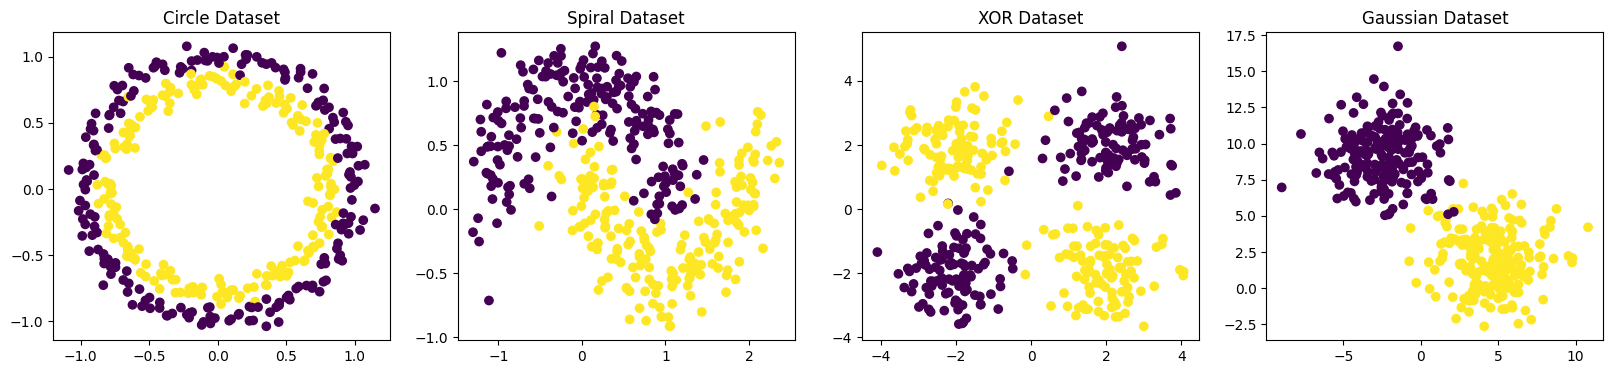

In [6]:
RANDOM_STATE = 42
SAMPLE_SIZE = 400

# Instantiate dataset
circle_dataset = CircleDataset(sample_size=SAMPLE_SIZE, random_state=RANDOM_STATE)
spiral_dataset = SpiralDataset(sample_size=SAMPLE_SIZE, random_state=RANDOM_STATE)
xor_dataset = XORDataset(sample_size=SAMPLE_SIZE, random_state=RANDOM_STATE)
gaussian_dataset = GaussianDataset(sample_size=SAMPLE_SIZE, random_state=RANDOM_STATE)

# Dataset information dictionary
dataset_info_dict = {
                     'Circle Dataset': {'dataset': circle_dataset, 'task': 'classification'},
                     'Spiral Dataset': {'dataset': spiral_dataset, 'task': 'classification'},
                     'XOR Dataset': {'dataset': xor_dataset, 'task': 'classification'},
                     "Gaussian Dataset": {'dataset': gaussian_dataset, 'task': 'classification'},
                    }

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(20, 4))

for index, dataset_name in zip(list(range(5)), dataset_info_dict):
    X, y = dataset_info_dict[dataset_name]['dataset'].get_complete_dataset()
    X = X.numpy()
    y = y.numpy().reshape(-1, 1)

    if dataset_info_dict[dataset_name]['task'] == 'classification':
        axes[index].scatter(X[:, 0], X[:, 1], c=y)
    else:
        axes[index].scatter(X[:, 0], X[:, 1])
    axes[index].set_title(f"{dataset_name}")

plt.show()

## Experiment Setup and Execution

In the next cell we will run 81 experiments per dataset (324 in total) to come to a conclusion whether Tanh does converge faster than Sigmoid function or not

In [7]:
# Setup experiment levers
ITERATIONS_PER_EXPERIMENT = 3
batch_size_list = [32, 64, 128]
learning_rate_list = [3e-3, 1e-2, 3e-2]
sample_size_list = [500, 1000, 2000]
dataset_info_dict = {
                        'circle_dataset': {
                                            'dataset_class': CircleDataset,
                                            'task': 'classification',
                                            'tanh_model': TanhClassificationModel(),
                                            'sigmoid_model': SigmoidClassificationModel(),
                                            'loss_function': torch.nn.BCEWithLogitsLoss()
                                          },
                        'spiral_dataset': {
                                            'dataset_class': SpiralDataset,
                                            'task': 'classification',
                                            'tanh_model': TanhClassificationModel(),
                                            'sigmoid_model': SigmoidClassificationModel(),
                                            'loss_function': torch.nn.BCEWithLogitsLoss()
                                          },
                        'xor_dataset': {
                                        'dataset_class': XORDataset,
                                        'task': 'classification',
                                        'tanh_model': TanhClassificationModel(),
                                        'sigmoid_model': SigmoidClassificationModel(),
                                        'loss_function': torch.nn.BCEWithLogitsLoss()
                                        },
                        'gaussian_dataset': {
                                                'dataset_class': GaussianDataset,
                                                'task': 'classification',
                                                'tanh_model': TanhClassificationModel(),
                                                'sigmoid_model': SigmoidClassificationModel(),
                                                'loss_function': torch.nn.BCEWithLogitsLoss()
                                            }
                    }

# Setup device
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Total number of experiments to be run
TOTAL_EXPERIMENTS = ITERATIONS_PER_EXPERIMENT * len(batch_size_list) * len(learning_rate_list) * len(sample_size_list) * len(dataset_info_dict) 

# Initialise counter
COUNTER = 0

# Create experiment's result's dictionary for storage
result_dict = {}
# Setup progress bar and run experiments
with tqdm(total=TOTAL_EXPERIMENTS, position=0) as progress_bar:
    for BATCH_SIZE in batch_size_list:
        for LEARNING_RATE in learning_rate_list:
            for SAMPLE_SIZE in sample_size_list:
                for DATASET_NAME in dataset_info_dict:
                    tanh_epoch_list = []
                    sigmoid_epoch_list = []
                    for i in range(ITERATIONS_PER_EXPERIMENT):
                        RANDOM_STATE = random.randint(0, 100)
                        dataset = dataset_info_dict[DATASET_NAME]['dataset_class'](sample_size=SAMPLE_SIZE, random_state=RANDOM_STATE)
                        # Get epoch values for tanh and sigmoid experiments
                        tanh_epoch = train_model(model=dataset_info_dict[DATASET_NAME]['tanh_model'],
                                                 dataset=dataset,
                                                 loss_function=dataset_info_dict[DATASET_NAME]['loss_function'],
                                                 batch_size=BATCH_SIZE,
                                                 learning_rate=LEARNING_RATE,
                                                 device=DEVICE
                                                 )
                        sigmoid_epoch = train_model(model=dataset_info_dict[DATASET_NAME]['sigmoid_model'],
                                                    dataset=dataset,
                                                    loss_function=dataset_info_dict[DATASET_NAME]['loss_function'],
                                                    batch_size=BATCH_SIZE,
                                                    learning_rate=LEARNING_RATE,
                                                    device=DEVICE
                                                    )
                        tanh_epoch_list.append(tanh_epoch)
                        sigmoid_epoch_list.append(sigmoid_epoch)
                        time.sleep(0.1)
                        # Update progress bar 
                        progress_bar.update(1)
                        progress_bar.set_postfix({
                                                    'DATASET_NAME': DATASET_NAME,
                                                    'DATASET_ITERATION': i + 1,
                                                    'BATCH_SIZE': BATCH_SIZE,
                                                    'LEARNING_RATE': LEARNING_RATE, 
                                                    'SAMPLE_SIZE': SAMPLE_SIZE
                                                    })
                    # Calculate average EPOCH per experiment
                    avg_tanh_epoch = round(sum(tanh_epoch_list) / ITERATIONS_PER_EXPERIMENT, 0)
                    avg_sigmoid_epoch =  round(sum(sigmoid_epoch_list) / ITERATIONS_PER_EXPERIMENT, 0)

                    if DATASET_NAME not in result_dict:
                        result_dict[DATASET_NAME] = {
                                                     'tanh_epoch_list': [],
                                                     'sigmoid_epoch_list': []
                                                    }
                    result_dict[DATASET_NAME]['tanh_epoch_list'].append(avg_tanh_epoch)
                    result_dict[DATASET_NAME]['sigmoid_epoch_list'].append(avg_sigmoid_epoch)

# Save the results
with result_abs_path.open('w') as file:
    json.dump(result_dict, file)

print("Completed All experiments...")

  0%|          | 0/324 [00:00<?, ?it/s]

Completed All experiments...


## Plotting Comparision Graphs

We will plot the graphs for each dataset.
- The graphs will be comparison graphs using barplots for each graph.
- The runs which reached the threshold within 1 epoch will not be included (This is because due to the weights initialization and the amount of data that allowed for faster learning within the same epoch)
- The bar plots will represent the average epochs required by the models to reach the threshold 


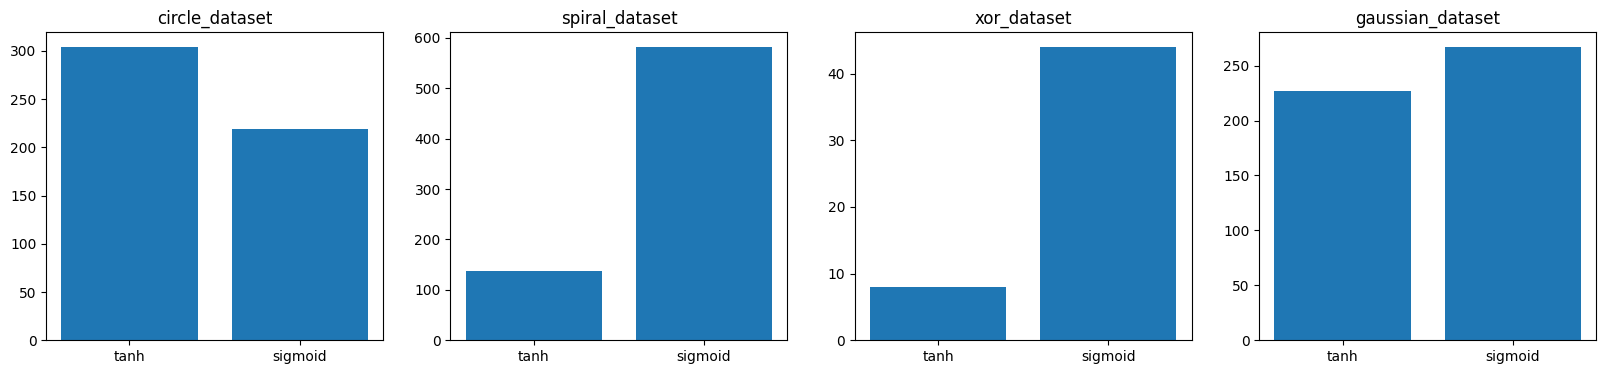

In [8]:
# Load the results from the stored file
with Path(result_abs_path).open() as file:
    result_dict = json.load(file)

result_dict_len = len(result_dict)

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(20, 4))

# Loop through the dataset and plot the results
for i, dataset_name in zip(range(result_dict_len), result_dict):
    tanh_result = [value for value in result_dict[dataset_name]['tanh_epoch_list'] if value > 1]
    sigmoid_result = [value for value in result_dict[dataset_name]['sigmoid_epoch_list'] if value > 1]
    tanh_avg = round(sum(tanh_result) / len(tanh_result), 0)
    sigmoid_avg = round(sum(sigmoid_result) / len(sigmoid_result), 0)

    axes[i].bar(['tanh', 'sigmoid'], [tanh_avg, sigmoid_avg])
    axes[i].set_title(dataset_name)

plt.show()

## Conclusion

From the results (displayed as bar charts above) we compare how quickly models learn using tanh and sigmoid activation functions. We observe that for **3 out of the 4** datasets models using tanh as the non-linear activation function converge faster.

This raises the question: **why do models using sigmoid appear to converge faster on the fourth dataset (the circle dataset)?**

It is important to note that we exclude cases where the model converged within 2 epochs. Upon closer inspection of the circle dataset results:
- Tanh:
    - 27 experiments converged within 2 epochs
    - 1 experiment took 304 epochs
- Sigmoid:
    - 17 experiments converged within 2 epochs
    - 3 experiments took 3 epochs, 1 took 2 epochs
    - 2 experiments exceeded 1000 epochs (did not effectively converge)
    - Remaining experiments: 116, 31, 16 and  13 epochs

The lower average convergence time for sigmoid is influenced by a larger number of very fast runs (≤2 epochs). When we consider individual runs sigmoid higher converges slowly or fails to converge.

Therefore despite the average suggesting otherwise tanh demonstrates more consistent and reliable convergence behavior compared to sigmoid.